# 02b — Technical Indicators & Feature Selection

Adds price-based technical indicators (RSI, MACD, Bollinger Bands) to the feature
matrix, then uses Random Forest importance to identify which features carry predictive
signal for daily silver log-returns.

**Primary method**: RF importance — model-agnostic, captures non-linear relationships,
consistent with the tree-based models used in the thesis.

**Alternative**: LASSO (Section 4b) — useful if you want linear-only selection,
e.g. to pick exogenous variables specifically for ARIMAX.

**Output**: updated `train.csv`, `val.csv`, `test.csv` with indicator columns, plus
`selected_features.csv`. Run after `02_features.ipynb`, before model notebooks.

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
import warnings, os
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120

RAW  = '../data/raw/'
PROC = '../data/processed/'

## 1. Compute technical indicators

All indicators are computed on the full price history before splitting, so edge effects
at split boundaries are avoided. Only close prices are needed (no OHLC).

In [20]:
prices = pd.read_csv(RAW + 'daily_prices.csv', index_col=0, parse_dates=True)
silver = prices['silver']

# ── RSI ──────────────────────────────────────────────────────────────────────
def rsi(s, window=14):
    delta     = s.diff()
    gain      = delta.clip(lower=0)
    loss      = -delta.clip(upper=0)
    avg_gain  = gain.ewm(span=window, min_periods=window, adjust=False).mean()
    avg_loss  = loss.ewm(span=window, min_periods=window, adjust=False).mean()
    rs        = avg_gain / avg_loss.replace(0, np.nan)
    return 100 - (100 / (1 + rs))

# ── MACD ─────────────────────────────────────────────────────────────────────
def macd(s, fast=12, slow=26, signal=9):
    ema_fast   = s.ewm(span=fast,   adjust=False).mean()
    ema_slow   = s.ewm(span=slow,   adjust=False).mean()
    macd_line  = ema_fast - ema_slow
    signal_line= macd_line.ewm(span=signal, adjust=False).mean()
    histogram  = macd_line - signal_line
    return macd_line, signal_line, histogram

# ── Bollinger Bands ───────────────────────────────────────────────────────────
def bollinger(s, window=20, num_std=2):
    ma        = s.rolling(window).mean()
    std       = s.rolling(window).std()
    upper     = ma + num_std * std
    lower     = ma - num_std * std
    bandwidth = (upper - lower) / ma          # volatility measure
    pct_b     = (s - lower) / (upper - lower) # position within bands [0, 1]
    return bandwidth, pct_b

# ── Price / MA ratios ─────────────────────────────────────────────────────────
def price_ma_ratio(s, window):
    return s / s.rolling(window).mean() - 1

# ── Rate of change ───────────────────────────────────────────────────────────
def roc(s, window):
    return s.pct_change(window)

# Build indicator DataFrame
ind = pd.DataFrame(index=prices.index)

ind['rsi_14']        = rsi(silver, 14)
ind['rsi_28']        = rsi(silver, 28)

ml, sl, hist         = macd(silver, 12, 26, 9)
ind['macd_line']     = ml
ind['macd_signal']   = sl
ind['macd_hist']     = hist

bw, pb               = bollinger(silver, 20, 2)
ind['bb_bandwidth']  = bw
ind['bb_pct_b']      = pb

ind['price_ma5']     = price_ma_ratio(silver, 5)
ind['price_ma21']    = price_ma_ratio(silver, 21)
ind['price_ma50']    = price_ma_ratio(silver, 50)

ind['roc_5d']        = roc(silver, 5)
ind['roc_21d']       = roc(silver, 21)

# Lag all indicators by 1 day — we use yesterday's indicator to predict today's return
ind = ind.shift(1)

print(f'Indicators computed: {ind.columns.tolist()}')
print(f'NaN rows at start:   {ind.isna().any(axis=1).sum()}')

Indicators computed: ['rsi_14', 'rsi_28', 'macd_line', 'macd_signal', 'macd_hist', 'bb_bandwidth', 'bb_pct_b', 'price_ma5', 'price_ma21', 'price_ma50', 'roc_5d', 'roc_21d']
NaN rows at start:   274


## 2. Merge into existing processed CSVs

In [21]:
for split in ['train', 'val', 'test']:
    path = PROC + f'{split}.csv'
    df   = pd.read_csv(path, index_col=0, parse_dates=True)

    # Drop indicator cols if already present from a previous run
    df = df.drop(columns=[c for c in ind.columns if c in df.columns])

    df = df.join(ind.reindex(df.index), how='left')
    df.to_csv(path)
    print(f'{split}.csv: {df.shape}  new cols added: {[c for c in ind.columns if c in df.columns]}')

train.csv: (1755, 50)  new cols added: ['rsi_14', 'rsi_28', 'macd_line', 'macd_signal', 'macd_hist', 'bb_bandwidth', 'bb_pct_b', 'price_ma5', 'price_ma21', 'price_ma50', 'roc_5d', 'roc_21d']
val.csv: (251, 50)  new cols added: ['rsi_14', 'rsi_28', 'macd_line', 'macd_signal', 'macd_hist', 'bb_bandwidth', 'bb_pct_b', 'price_ma5', 'price_ma21', 'price_ma50', 'roc_5d', 'roc_21d']
test.csv: (837, 50)  new cols added: ['rsi_14', 'rsi_28', 'macd_line', 'macd_signal', 'macd_hist', 'bb_bandwidth', 'bb_pct_b', 'price_ma5', 'price_ma21', 'price_ma50', 'roc_5d', 'roc_21d']


## 3. Random Forest feature importance

Train a RF on the full training set and rank features by Mean Decrease in Impurity (MDI).
Features above the mean importance are selected — this threshold keeps roughly the top half
and is easy to adjust. RF importance captures non-linear relationships, making it appropriate
for tree-based models and LSTM alike.

In [22]:
train = pd.read_csv(PROC + 'train.csv', index_col=0, parse_dates=True)

TARGET  = 'silver_return'
EXCLUDE = {'silver', TARGET}
all_cols = [c for c in train.columns if c not in EXCLUDE]

X = train[all_cols].fillna(0).values
y = train[TARGET].fillna(0).values

rf = RandomForestRegressor(n_estimators=300, max_depth=8, random_state=42, n_jobs=-1)
rf.fit(X, y)

imp = pd.Series(rf.feature_importances_, index=all_cols).sort_values(ascending=False)
threshold = imp.mean()
selected  = imp[imp >= threshold].index.tolist()

print(f'Threshold (mean importance): {threshold:.5f}')
print(f'Selected: {len(selected)} / {len(all_cols)} features\n')
print('Selected features:')
for f in selected:
    print(f'  {f:<30} {imp[f]:.5f}')

Threshold (mean importance): 0.02083
Selected: 4 / 48 features

Selected features:
  gold_return                    0.65081
  silver_vol_5d                  0.08314
  mom_5d                         0.05089
  copper_return                  0.02843


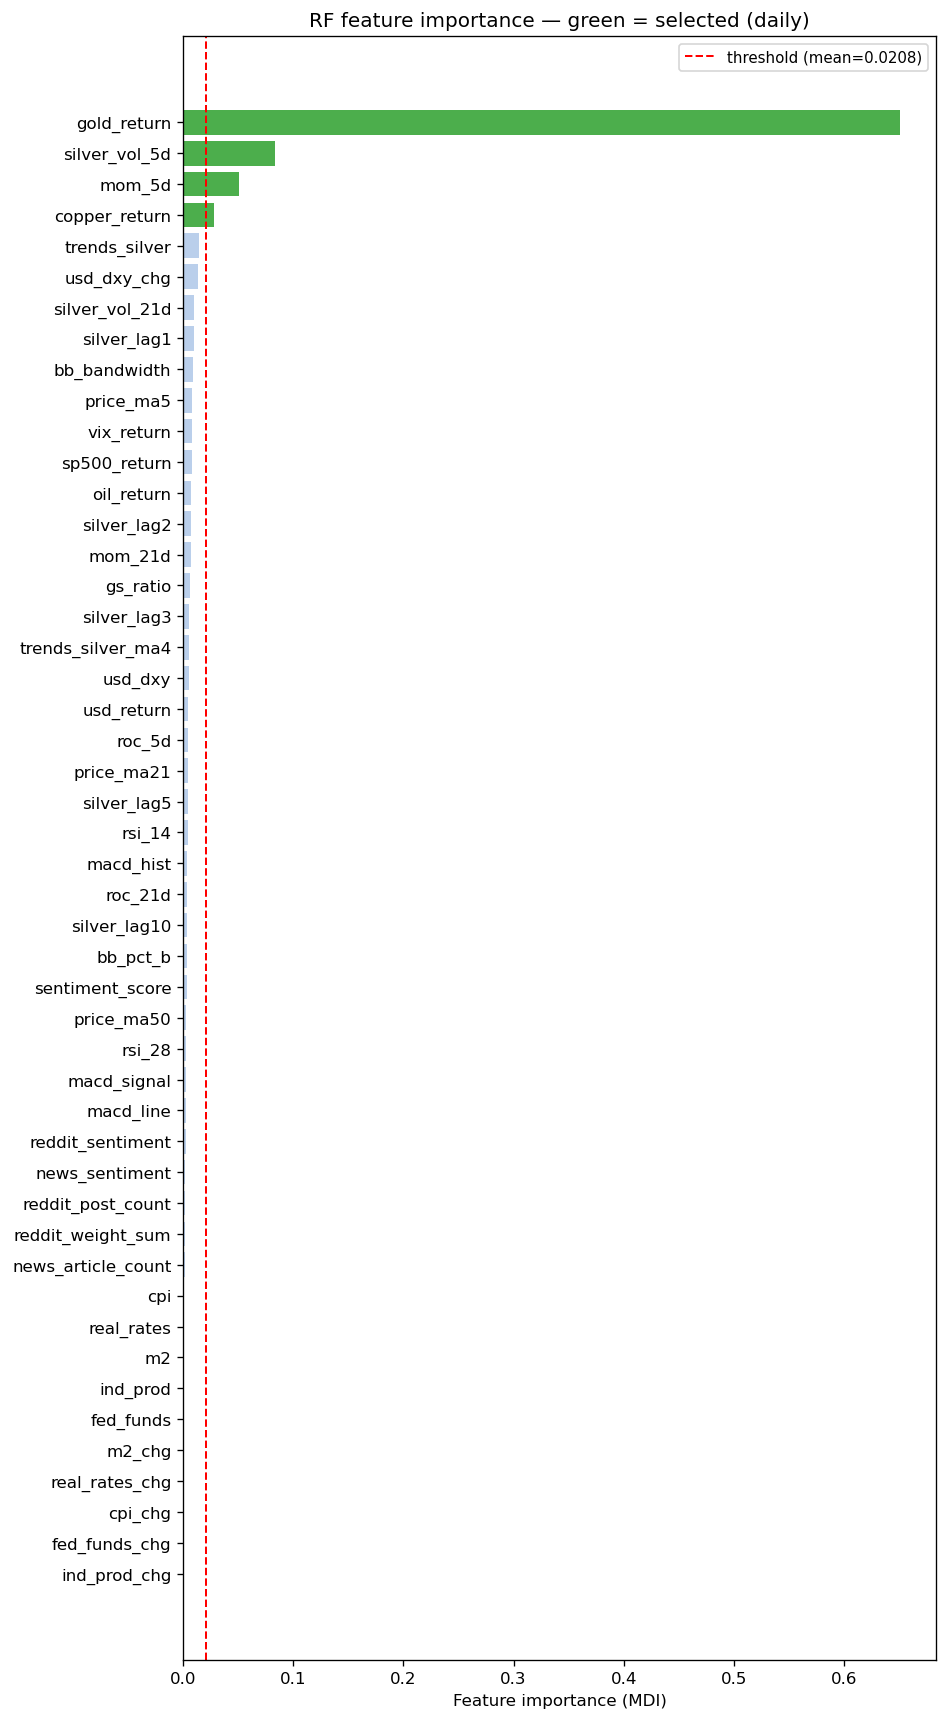

Saved selected_features_rf_daily.csv


In [23]:
fig, ax = plt.subplots(figsize=(8, max(4, len(imp) * 0.28 + 1)))
colors = ['#2ca02c' if f in selected else '#aec7e8' for f in imp.index]
ax.barh(imp.index[::-1], imp.values[::-1], color=colors[::-1], alpha=0.85)
ax.axvline(threshold, color='red', lw=1.2, ls='--', label=f'threshold (mean={threshold:.4f})')
ax.set_xlabel('Feature importance (MDI)')
ax.set_title('RF feature importance — green = selected (daily)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# Save — suffix makes purpose explicit: RF importance, daily frequency
out = pd.DataFrame({'feature': imp.index, 'importance': imp.values,
                    'selected': imp.index.isin(selected)})
out.to_csv(PROC + 'selected_features_rf_daily.csv', index=False)
print('Saved selected_features_rf_daily.csv')

## 4. LASSO selection — for linear models (ARIMAX, VAR, MIDAS)

LASSO penalises coefficients toward zero, shrinking uninformative features to exactly zero.
This is the appropriate selection method for **linear models** where multicollinearity
and too many regressors genuinely hurt:

- **ARIMAX**: OLS with extra regressors — extra correlated indicators inflate standard errors.
- **VAR**: models every variable jointly; each extra indicator adds parameters to every equation.
- **MIDAS**: linear lag polynomial — same concern.

RF and XGBoost handle many correlated features natively; LASSO is not needed there.

Output: `selected_features_lasso.csv` with the LASSO-selected subset for linear models.

Alpha chosen by CV:  0.000032
Raw non-zero:        33 / 48
Above threshold (|coef| > 0.005): 6

mom_5d         0.032235
price_ma5     -0.031324
roc_5d        -0.016382
silver_lag1    0.016092
silver_lag2    0.010341
silver_lag5    0.007611


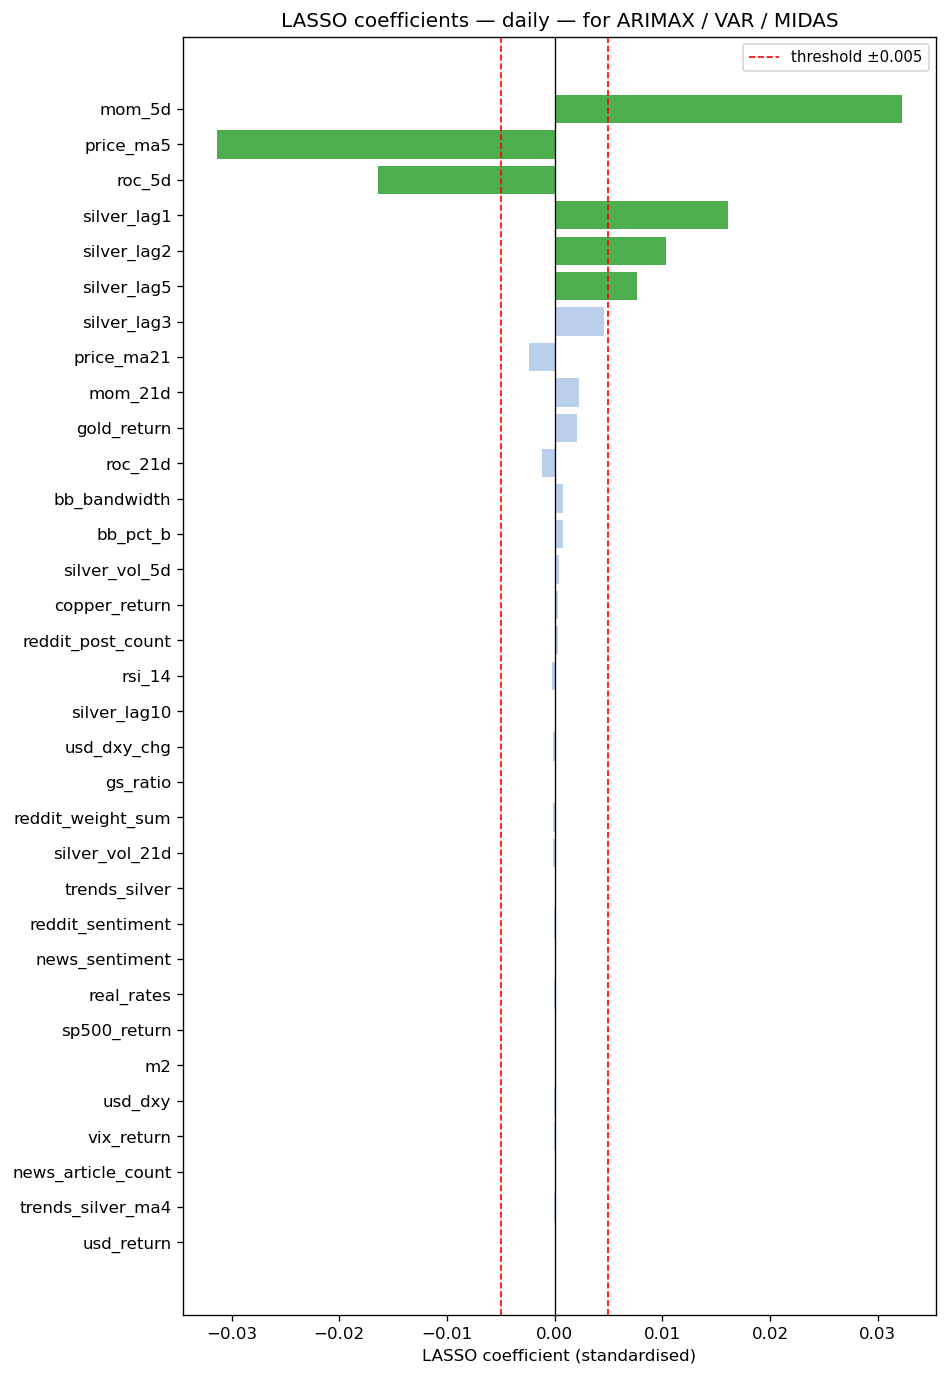


Saved selected_features_lasso_daily.csv  (6 features selected)


In [24]:
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)
tscv     = TimeSeriesSplit(n_splits=5)
lasso    = LassoCV(cv=tscv, max_iter=10000, n_alphas=100, random_state=42)
lasso.fit(X_scaled, y)

lasso_coef = pd.Series(lasso.coef_, index=all_cols)

# Strict threshold: |coef| > 0.005
THRESHOLD = 0.005
lasso_selected = lasso_coef[lasso_coef.abs() > THRESHOLD].sort_values(key=abs, ascending=False)

print(f'Alpha chosen by CV:  {lasso.alpha_:.6f}')
print(f'Raw non-zero:        {(lasso_coef != 0).sum()} / {len(all_cols)}')
print(f'Above threshold (|coef| > {THRESHOLD}): {len(lasso_selected)}\n')
print(lasso_selected.to_string())

# Plot
lasso_nonzero = lasso_coef[lasso_coef != 0].sort_values(key=abs, ascending=False)
fig, ax = plt.subplots(figsize=(8, max(4, len(lasso_nonzero) * 0.32 + 1)))
colors = ['#2ca02c' if abs(v) > THRESHOLD else '#aec7e8' for v in lasso_nonzero.values]
ax.barh(lasso_nonzero.index[::-1], lasso_nonzero.values[::-1], color=colors[::-1], alpha=0.85)
ax.axvline(0, color='black', lw=0.8)
ax.axvline( THRESHOLD, color='red', lw=1, ls='--', label=f'threshold ±{THRESHOLD}')
ax.axvline(-THRESHOLD, color='red', lw=1, ls='--')
ax.set_xlabel('LASSO coefficient (standardised)')
ax.set_title('LASSO coefficients — daily — for ARIMAX / VAR / MIDAS')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# Save — suffix makes purpose explicit: LASSO selection, daily frequency
lasso_out = pd.DataFrame({
    'feature':  all_cols,
    'coef':     lasso_coef.values,
    'selected': lasso_coef.abs().values > THRESHOLD,
})
lasso_out.to_csv(PROC + 'selected_features_lasso_daily.csv', index=False)
print(f'\nSaved selected_features_lasso_daily.csv  ({len(lasso_selected)} features selected)')

## 5. How to use in daily model notebooks

**Daily RF / XGBoost / LSTM** — use RF importance selection:
```python
feat = pd.read_csv('../../data/processed/selected_features_rf_daily.csv')
TECH_COLS = feat.loc[feat['selected'], 'feature'].tolist()
```

**Daily ARIMAX / VAR / MIDAS** — use LASSO selection:
```python
feat = pd.read_csv('../../data/processed/selected_features_lasso_daily.csv')
TECH_COLS = feat.loc[feat['selected'], 'feature'].tolist()
```

For the weekly equivalents see `02c_technical_features_weekly.ipynb` which produces
`selected_features_rf_weekly.csv` and `selected_features_lasso_weekly.csv`.